In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("amazon_reviews_cleaned.csv")

In [9]:
df.shape

(568401, 10)

In [10]:
df["Rating"].value_counts().sort_index()

Rating
1     52264
2     29743
3     42638
4     80654
5    363102
Name: count, dtype: int64

In [11]:
(df["Rating"].value_counts(normalize=True) * 100).sort_index()

Rating
1     9.194917
2     5.232749
3     7.501394
4    14.189630
5    63.881309
Name: proportion, dtype: float64

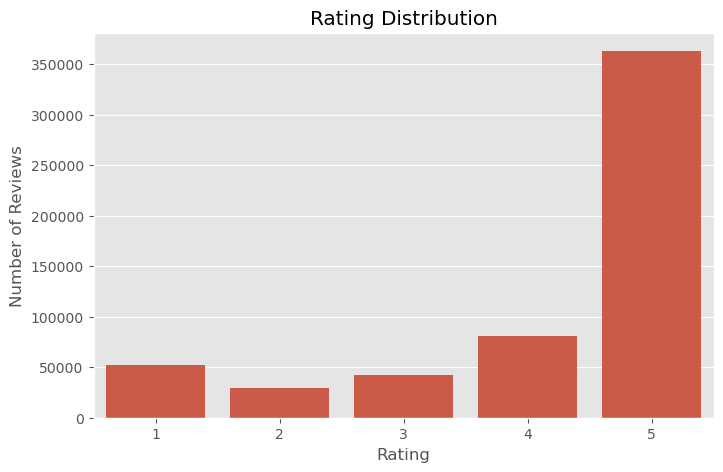

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Rating")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [14]:
df["Rating"].mean()

4.183296651483723

In [15]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Rating,Time,Review_Summary,Review
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...


In [16]:
df["Time"].dtype

<StringDtype(na_value=nan)>

In [17]:
df["Time"] = pd.to_datetime(df["Time"])

In [18]:
df["Time"].dtype

dtype('<M8[us]')

In [19]:
df["Year"] = df["Time"].dt.year
df["Month"] = df["Time"].dt.month_name()

In [21]:
df["Year"].value_counts().sort_index()

Year
1999         6
2000        32
2001        13
2002        73
2003       132
2004       561
2005      1335
2006      6671
2007     22275
2008     34163
2009     55326
2010     85880
2011    163289
2012    198645
Name: count, dtype: int64

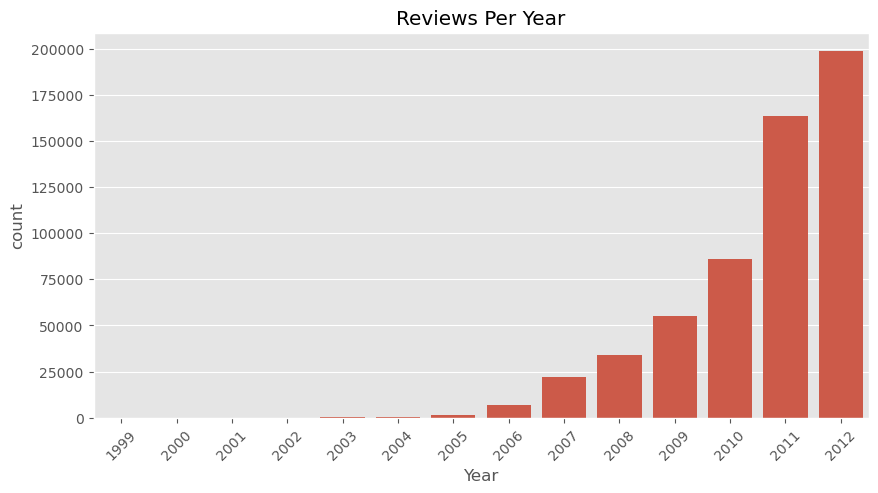

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Year")

plt.title("Reviews Per Year")
plt.xticks(rotation=45)

plt.show()

In [25]:
top_products = df["ProductId"].value_counts().head(10)

top_products

ProductId
B007JFMH8M    913
B002QWP89S    632
B0026RQTGE    632
B002QWHJOU    632
B002QWP8H0    632
B003B3OOPA    623
B001EO5Q64    567
B0013NUGDE    564
B007M83302    564
B000VK8AVK    564
Name: count, dtype: int64

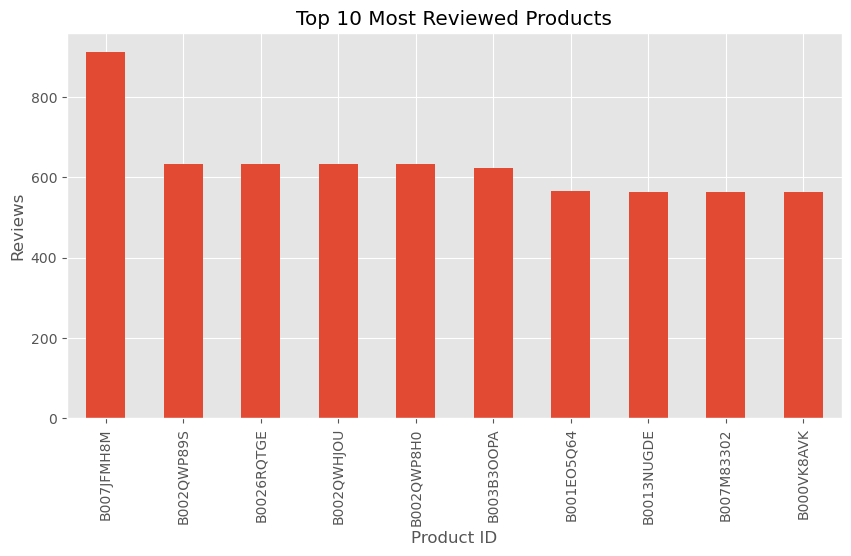

In [26]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Product ID")
plt.ylabel("Reviews")

plt.show()

In [27]:
top_users = df["UserId"].value_counts().head(10)

top_users

UserId
A3OXHLG6DIBRW8    448
A1YUL9PCJR3JTY    421
AY12DBB0U420B     389
A281NPSIMI1C2R    365
A1Z54EM24Y40LL    256
A1TMAVN4CEM8U8    204
A2MUGFV2TDQ47K    201
A3TVZM3ZIXG8YW    199
A3PJZ8TU8FDQ1K    178
AQQLWCMRNDFGI     176
Name: count, dtype: int64

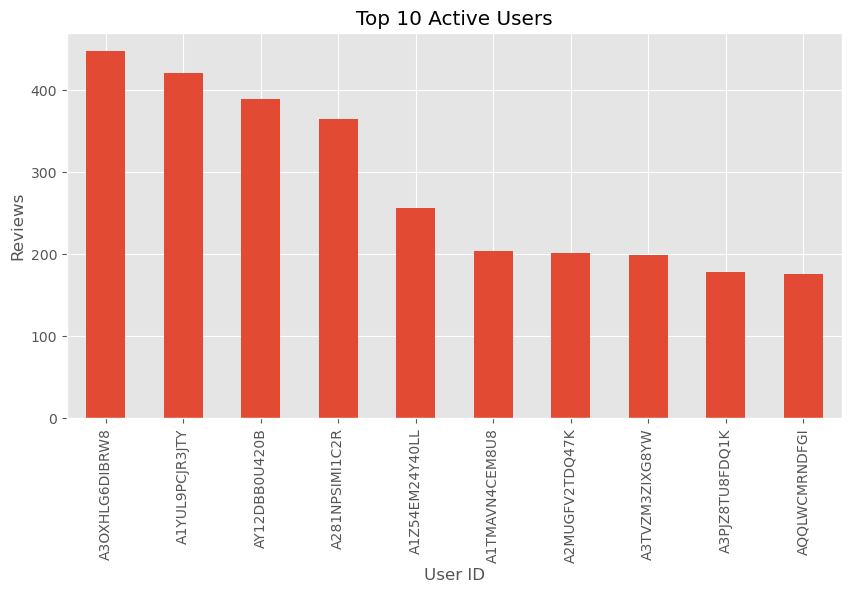

In [28]:
plt.figure(figsize=(10,5))

top_users.plot(kind="bar")

plt.title("Top 10 Active Users")
plt.xlabel("User ID")
plt.ylabel("Reviews")

plt.show()

In [29]:
df.groupby("Year")["Rating"].mean()

Year
1999    5.000000
2000    4.531250
2001    3.538462
2002    4.712329
2003    4.325758
2004    4.392157
2005    4.445693
2006    4.313446
2007    4.394029
2008    4.345344
2009    4.300365
2010    4.198882
2011    4.143825
2012    4.117848
Name: Rating, dtype: float64

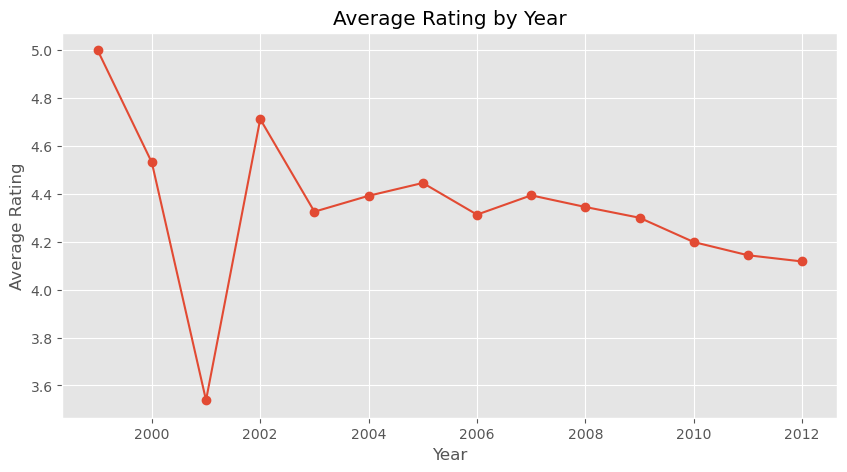

In [30]:
plt.figure(figsize=(10,5))

df.groupby("Year")["Rating"].mean().plot(marker="o")

plt.title("Average Rating by Year")
plt.ylabel("Average Rating")

plt.show()

In [31]:
df["Helpfulness_Ratio"] = (
    df["HelpfulnessNumerator"] /
    df["HelpfulnessDenominator"]
)

In [32]:
df["Helpfulness_Ratio"] = df["Helpfulness_Ratio"].fillna(0)

In [33]:
df["Helpfulness_Ratio"].mean()

0.4078897258663468

In [34]:
df["Review_Length"] = df["Review"].str.len()

In [35]:
df["Review_Length"].describe()

count    568401.000000
mean        436.246170
std         445.351629
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: Review_Length, dtype: float64

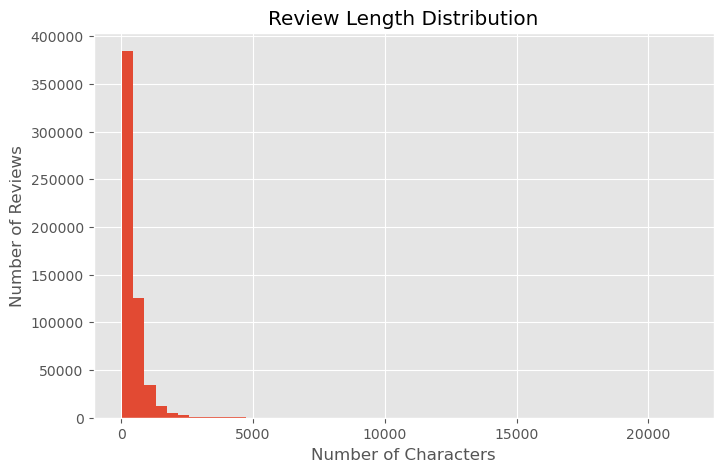

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Review_Length"], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.show()

In [37]:
df.groupby("Rating")["Review_Length"].mean()

Rating
1    478.088608
2    490.961873
3    520.337680
4    496.604583
5    402.459785
Name: Review_Length, dtype: float64

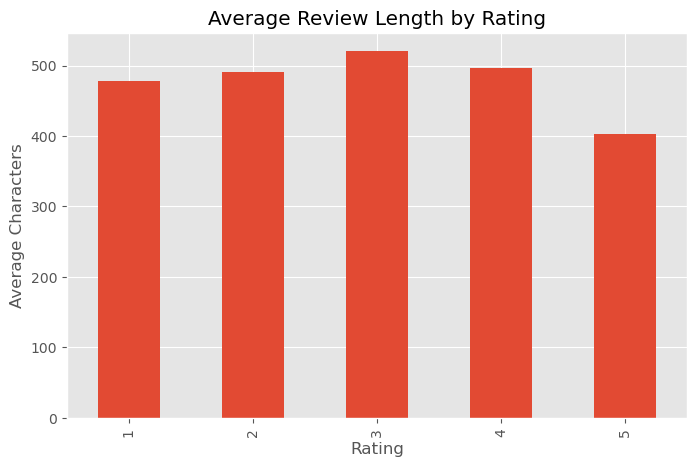

In [38]:
plt.figure(figsize=(8,5))

df.groupby("Rating")["Review_Length"].mean().plot(kind="bar")

plt.title("Average Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Characters")

plt.show()

In [39]:
df.groupby("Rating").size()

Rating
1     52264
2     29743
3     42638
4     80654
5    363102
dtype: int64

In [40]:
numeric_df = df.select_dtypes(include=["number"])

In [41]:
numeric_df.corr()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Rating,Year,Helpfulness_Ratio,Review_Length
Id,1.000000,0.001224,0.000760,0.010715,0.007524,-0.001427,-0.012618
HelpfulnessNumerator,0.001224,1.000000,0.974849,-0.032593,-0.153663,0.242197,0.170827
HelpfulnessDenominator,0.000760,0.974849,1.000000,-0.097806,-0.171552,0.218055,0.175602
Rating,0.010715,-0.032593,-0.097806,1.000000,-0.061828,0.028079,-0.077384
Year,0.007524,-0.153663,-0.171552,-0.061828,1.000000,-0.259784,0.027103
Helpfulness_Ratio,-0.001427,0.242197,0.218055,0.028079,-0.259784,1.000000,0.123306
Review_Length,-0.012618,0.170827,0.175602,-0.077384,0.027103,0.123306,1.000000


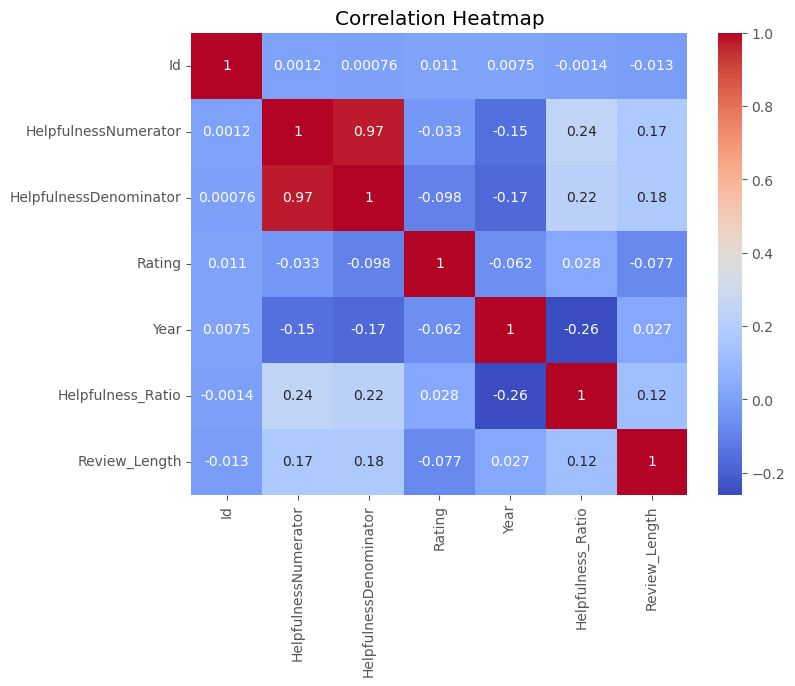

In [42]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()